In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv")

This section imports `pandas` and `numpy` *(currently unused)* and reads the raw data.

In [2]:
df_clean = df.copy()

df_clean["User_Score"] = pd.to_numeric(df_clean["User_Score"], errors="coerce")
df_clean["Year_of_Release"] = pd.to_datetime(df_clean["Year_of_Release"].astype("Int64"), format='%Y')

df_clean = df_clean.dropna(subset=['Name','Year_of_Release','Genre'])
df_clean = df_clean.dropna(subset=['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count'], how="all")

for col in ["Critic_Score", "Critic_Count"]:
    df_clean[col] = df_clean.groupby(["Platform", "Year_of_Release", "Genre"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

for col in ["User_Score", "User_Count"]:
    df_clean[col] = df_clean.groupby(["Platform", "Year_of_Release", "Genre"])[col].transform(
        lambda x: x.fillna(x.mean())
    )
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

for col in ["Developer", "Rating", "Publisher"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

This section removes any pieces of data that are unknown, null, or NaN. 
- The `User_Score` column is converted to numeric type with `errors="coerce"` to remove the multiple instances of "tbd" in the original dataset.
- The `Year_of_Release` column is converted to int64 then to a date/time column storing 00:00:00 Jan 1 of the release year.
- Any row with a null `Name`, `Year_of_Release`, or `Genre` is removed, as these columns cannot be reasonably interpreted.
- Any row without a `Critic_Score`, `Critic_Count`, `User_Score`, *and* `User_Count` are removed.
- If a row does not have a `Critic_Score` or `Critic_Count`, those columns are filled with the average of games sharing the same `Platform`, `Year_of_Release`, and `Genre` as them, or the average of all reviews if none of these exist (~100 rows). The same applies for `User_Score` and `User_Count`.
- Any row with an null `Developer`, `Rating`, or `Publisher` has that valued replaced with "Unknown."

In [3]:
df_clean["Rating"] = df_clean["Rating"].replace({
    "K-A": "E", 
    "RP": "Unknown"
})

df_clean = df_clean[df_clean["Year_of_Release"].dt.year <= 2016]

This section removes outliers and invalid data.
- The ratings "*K-A*" and "*RP*" appear very few times in the dataset. "*K-A*" was replaced with "*E*" in 1998, while "*RP*" represents a pending rating that can be reliably grouped in with other unknown ratings.
- Since this dataset was created in December 2016, any data from after 2016 is removed.

In [4]:
df_clean["Genre"] = df_clean["Genre"].astype("category")
df_clean["Platform"] = df_clean["Platform"].astype("category")
df_clean["Rating"] = df_clean["Rating"].astype("category")

df_clean["Critic_Count"] = df_clean["Critic_Count"].round().astype("int64")
df_clean["User_Count"] = df_clean["User_Count"].round().astype("int64")

This section adjusts the types for some of the columns.
- The `Genre`, `Platform`, and `Rating` columns are changed to type `category` since there is a consistently reused list of a few distinct values for each column.
- The `Critic_Count` and `User_Count` column are changed to type `int64` since there cannot reasonably be a fraction of a critic or user.

In [5]:
df_clean.to_csv("../data/processed/videogamesales_clean.csv", index=False)

This line writes the cleaned data to a new `.csv` file at `/data/processed`.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

This section imports the `seaborn` and `matplotlib.pyplot` libraries to allow visualization of the data.

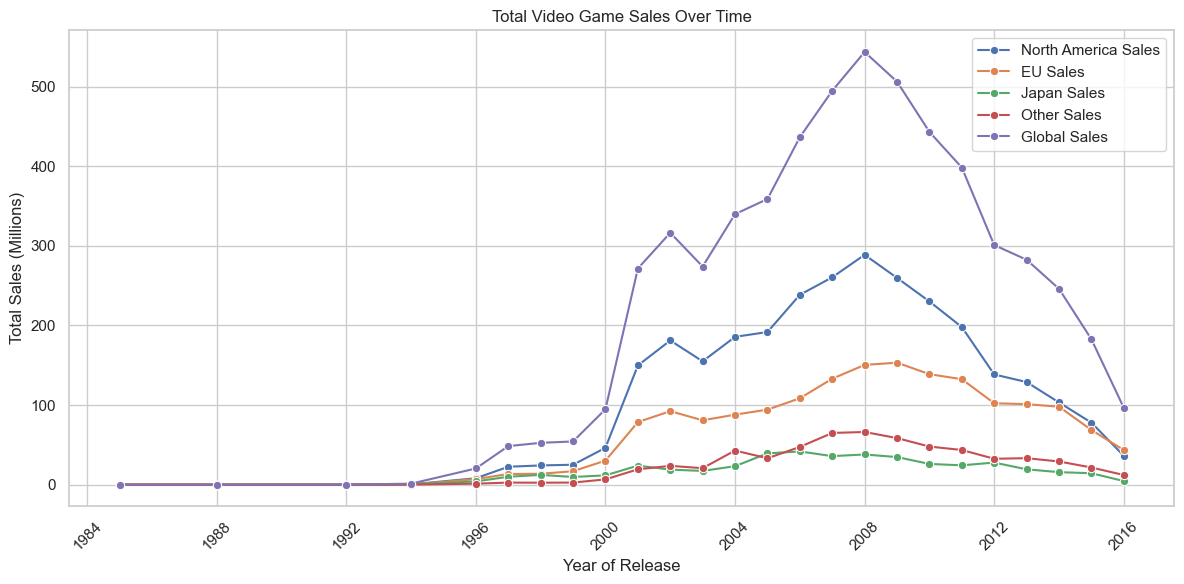

In [10]:
fig = plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x="Year_of_Release", y="NA_Sales", estimator="sum", errorbar=None, marker="o", label="North America Sales")
sns.lineplot(data=df_clean, x="Year_of_Release", y="EU_Sales", estimator="sum", errorbar=None, marker="o", label="EU Sales")
sns.lineplot(data=df_clean, x="Year_of_Release", y="JP_Sales", estimator="sum", errorbar=None, marker="o", label="Japan Sales")
sns.lineplot(data=df_clean, x="Year_of_Release", y="Other_Sales", estimator="sum", errorbar=None, marker="o", label="Other Sales")
sns.lineplot(data=df_clean, x="Year_of_Release", y="Global_Sales", estimator="sum", errorbar=None, marker="o", label="Global Sales")
plt.title("Total Video Game Sales Over Time")
plt.xlabel("Year of Release")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)
plt.legend()
fig.tight_layout()
plt.show()
fig.savefig("../figures/sales_over_time.png", dpi=300)


This section creates a line plot showing the total sales of video games over time, broken down by region (`Global_Sales`, `NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`). The plot is saved as a `.png` file in the `/figures` directory.

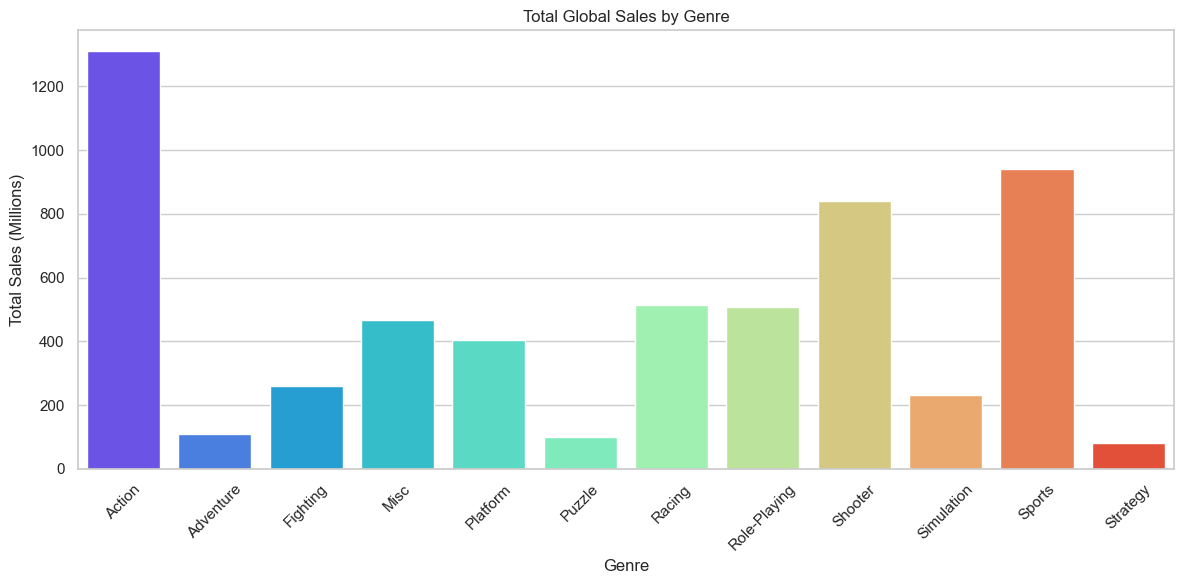

In [ ]:
fig = plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, x="Genre", y="Global_Sales", estimator="sum", errorbar=None, palette="rainbow", hue="Genre", dodge=False)
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Sales (Millions)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()
fig.savefig("../figures/sales_by_genre.png", dpi=300)

This section of code creates a bar plot showing the total global sales of video games by `Genre`. The plot is saved as a `.png` file in the `/figures` directory.

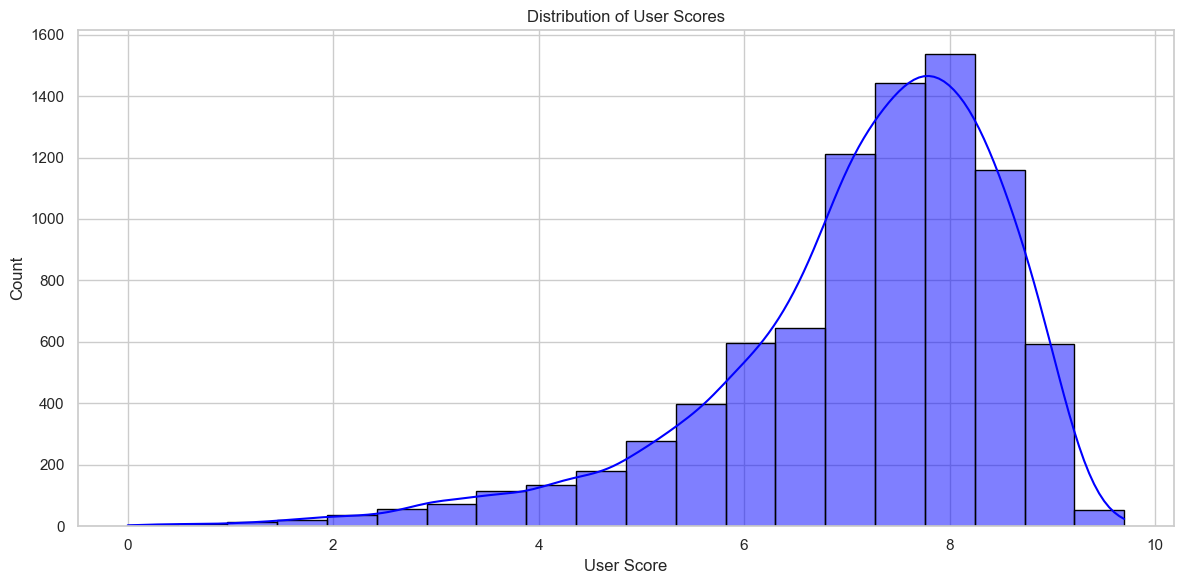

In [ ]:
fig = plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x="User_Score", bins=20, kde=True, color="blue", edgecolor="black")
plt.title("Distribution of User Scores")
plt.xlabel("User Score")
plt.ylabel("Count")
fig.tight_layout()
plt.show()
fig.savefig("../figures/user_score_distribution.png", dpi=300)

This section creates a histogram plot showing the distribution of user scores for video games. The x-axis represents the `User_Score` (ranging from 0 to 10), while the y-axis represents the count of games that received each score. The plot is saved as a `.png` file in the `/figures` directory.

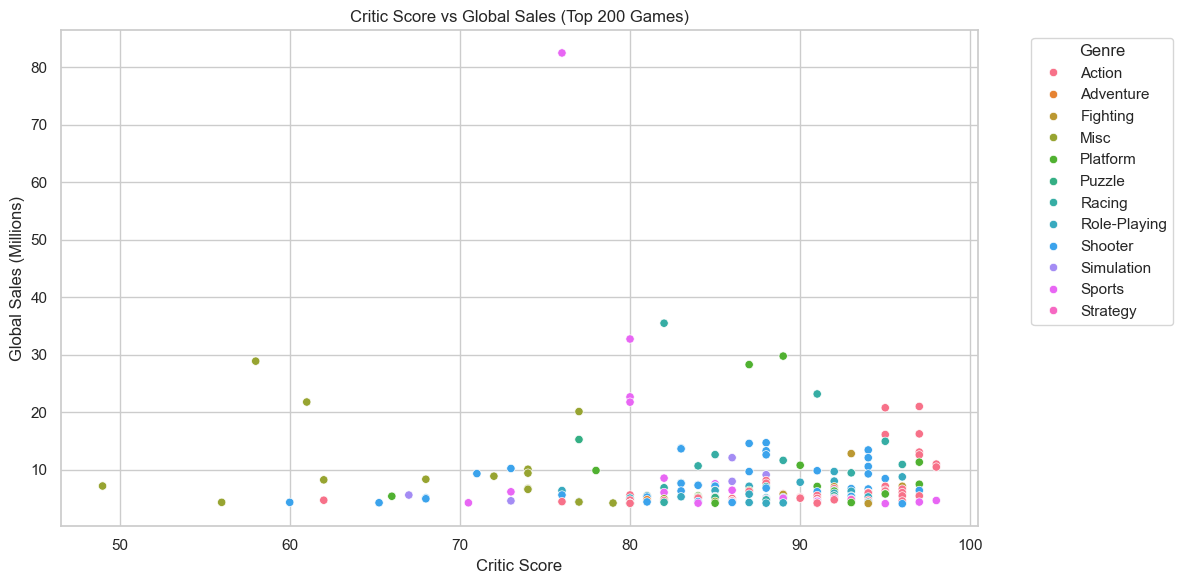

In [ ]:
top_sales = df_clean.nlargest(200, "Global_Sales")
fig = plt.figure(figsize=(12, 6))
sns.scatterplot(data=top_sales, x="Critic_Score", y="Global_Sales", hue="Genre", palette="husl")
plt.title("Critic Score vs Global Sales (Top 200 Games)")
plt.xlabel("Critic Score")
plt.ylabel("Global Sales (Millions)")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()
fig.savefig("../figures/critic_score_vs_sales.png", dpi=300)

This section creates a scatter plot of `Critic_Score` vs `Global_Sales` for the top 200 games by sales, colored by `Genre`. The plot is saved as a `.png` file in the `/figures` directory.